# Setup

In [1]:
# Minimal deps (idempotent). Uncomment supervision if you want annotation overlays for detections.
# %pip install -q huggingface_hub ultralytics opencv-python matplotlib tqdm
# %pip install -q supervision

In [2]:
from pathlib import Path
import os
import random
import threading
import time
from concurrent.futures import ThreadPoolExecutor
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple, Union, cast

import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import numpy as np
import numpy.typing as npt
import supervision as sv
from sklearn.cluster import KMeans
from ultralytics import YOLO

In [3]:
# General paths
PROJECT_ROOT = Path.cwd().parent.parent.parent
print(f"Project Root: {PROJECT_ROOT}")
RESOURCES_DIR = PROJECT_ROOT / "Resources"
MODELS_DIR = RESOURCES_DIR / "Models"
DATASET_DIR = Path(r"D:\Project\FootballAnalytix\Data\Sample")

# Model paths
PLAYERS_MODEL_PATH = MODELS_DIR / "Players.pt"
FIELD_MODEL_PATH = MODELS_DIR / "Fields.pt"

# Video/data inputs
DEFAULT_VIDEO_PATH = DATASET_DIR / "Video.mp4"
DEFAULT_PITCH_IMAGE = DATASET_DIR / "Pitch.png"
CLEANED_DATASET_DIR = DATASET_DIR / "SNGS-131" / "Frames"

# Visualization/constants
MINIMAP_SCALE = 0.1
MINIMAP_PADDING = 50
TEAM_COLORS_BGR = [
    (0, 0, 255),  # Team 0 - red
    (255, 0, 0),  # Team 1 - blue
]
HUD_COLOR = (0, 255, 0)
UNASSIGNED_COLOR = (0, 215, 255)
DEFAULT_OTHER_COLOR = (0, 255, 0)
MINIMAP_KEYPOINT_COLOR = (255, 255, 255)
CONFIDENCE_THRESHOLD = 0.65
REASSIGN_INTERVAL = 300  # frames
MAX_COLOR_SAMPLES = 200
DEFAULT_MINIMAP_RADIUS = 10

# Per-class configuration (adjust ids/colors per dataset)
CLASS_CONFIG = {
    "player": {
        "ids": [1],
        "color": (0, 0, 255),
        "legend": "Player",
        "is_player": True,
        "show_on_minimap": True,
        "minimap_radius": 12,
    },
    "ball": {
        "ids": [3],
        "color": (0, 255, 255),
        "legend": "Ball",
        "is_player": False,
        "show_on_minimap": True,
        "minimap_radius": 10,
    },
    "referee": {
        "ids": [0],
        "color": (204, 0, 255),
        "legend": "Referee",
        "is_player": False,
        "show_on_minimap": True,
        "minimap_radius": 10,
    },
    "goalkeeper": {
        "ids": [2],
        "color": (0, 165, 255),
        "legend": "Goalkeeper",
        "is_player": False,
        "show_on_minimap": True,
        "minimap_radius": 10,
    }
}

CLASS_ID_LOOKUP: Dict[int, str] = {}
for class_name, cfg in CLASS_CONFIG.items():
    cfg.setdefault("legend", class_name.title())
    cfg.setdefault("color", DEFAULT_OTHER_COLOR)
    cfg.setdefault("is_player", False)
    cfg.setdefault("show_on_minimap", True)
    cfg.setdefault("minimap_radius", DEFAULT_MINIMAP_RADIUS)
    for class_id in cfg.get("ids", []):
        CLASS_ID_LOOKUP[int(class_id)] = class_name

Project Root: d:\Project\FutsalCV


In [4]:
def get_model_label(model, class_id: int) -> str:
    """Return a readable class label from a YOLO model, with safe fallbacks."""
    names = getattr(getattr(model, "model", None), "names", None)
    if names is None:
        names = getattr(model, "names", None)
    if isinstance(names, dict):
        return str(names.get(class_id, f"class_{class_id}"))
    if isinstance(names, (list, tuple)) and 0 <= class_id < len(names):
        return str(names[class_id])
    return f"class_{class_id}"


def bgr_to_rgb_norm(color: Tuple[int, int, int]) -> Tuple[float, float, float]:
    """Convert a BGR color tuple in 0-255 space to normalized RGB for Matplotlib."""
    b, g, r = color
    return (r / 255.0, g / 255.0, b / 255.0)


def resolve_class_metadata(
    class_id: int,
    model,
) -> Tuple[str, Tuple[int, int, int], bool, bool, int, Dict[str, object]]:
    """Map a class id to configured metadata with sensible fallbacks."""
    class_name = CLASS_ID_LOOKUP.get(class_id)
    class_config = CLASS_CONFIG.get(class_name, {}) if class_name else {}
    legend_name = class_config.get("legend") or (
        class_name.title() if class_name else get_model_label(model, class_id)
    )
    class_color = tuple(class_config.get("color", DEFAULT_OTHER_COLOR))
    is_player = bool(class_config.get("is_player", False))
    show_on_minimap = bool(class_config.get("show_on_minimap", True))
    minimap_radius = int(class_config.get("minimap_radius", DEFAULT_MINIMAP_RADIUS))
    return (
        legend_name,
        class_color,
        is_player,
        show_on_minimap,
        minimap_radius,
        class_config,
    )

# Players

#### Inference

In [5]:
players_model = YOLO(str(PLAYERS_MODEL_PATH))
print(f"Loaded players model from {PLAYERS_MODEL_PATH}")

Loaded players model from d:\Project\FutsalCV\Resources\Models\Players.pt


#### Clustering

In [6]:
def _extract_jersey_color(frame_rgb: np.ndarray, box_xyxy: np.ndarray) -> Optional[np.ndarray]:
    """Return mean RGB color from the upper half of a player's bounding box."""
    x1, y1, x2, y2 = map(int, box_xyxy)
    player_crop = frame_rgb[y1:y2, x1:x2]
    if player_crop.size == 0:
        return None
    upper_half = player_crop[: max(1, player_crop.shape[0] // 2), :]
    if upper_half.size == 0:
        return None
    return upper_half.reshape(-1, 3).mean(axis=0)


def collect_initial_team_colors(
    cap: cv2.VideoCapture,
    model: YOLO,
    num_frames: int = 30,
    conf: float = CONFIDENCE_THRESHOLD,
    return_samples: bool = False,
) -> Union[np.ndarray, Tuple[Optional[np.ndarray], List[np.ndarray]]]:
    """Collect initial jersey colors to bootstrap KMeans clustering."""
    initial_colors: List[np.ndarray] = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or num_frames
    target_frames = min(num_frames, total_frames)

    # Select random frame indices
    random_indices = random.sample(range(total_frames), target_frames)
    random_indices.sort()  # Sort to minimize seeking

    print(f"Collecting jersey samples from {target_frames} random frames...")

    for idx in random_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            continue
        results = model.predict(source=frame, conf=conf, verbose=False)
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        for box in results[0].boxes:
            if int(box.cls[0]) != 2:
                continue
            color = _extract_jersey_color(frame_rgb, box.xyxy[0])
            if color is not None:
                initial_colors.append(color)

    if len(initial_colors) < 2:
        warning = (
            f"Only collected {len(initial_colors)} player samples; continuing without initializing team colors."
        )
        print(warning)
        if return_samples:
            return None, initial_colors
        raise RuntimeError("Not enough player samples to establish team colors.")

    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    kmeans.fit(np.array(initial_colors))
    centers = kmeans.cluster_centers_
    print("Team color centers (RGB):\n", centers)
    if return_samples:
        return centers, initial_colors
    return centers


def assign_player_team(jersey_color: np.ndarray, team_color_centers: np.ndarray) -> int:
    dist = np.linalg.norm(team_color_centers - jersey_color, axis=1)
    return int(np.argmin(dist))


def reassign_all_teams(
    player_teams: Dict[int, int],
    current_colors: Dict[int, np.ndarray],
    team_color_centers: np.ndarray,
) -> Dict[int, int]:
    switches = 0
    updated: Dict[int, int] = {}
    for track_id, color in current_colors.items():
        new_team = assign_player_team(color, team_color_centers)
        if player_teams.get(track_id, new_team) != new_team:
            switches += 1
        updated[track_id] = new_team
    if switches:
        print(f"Reassigned {switches} players to stabilize teams")
    return updated

# Fields

#### Keypoints Detection

In [7]:
field_model = YOLO(str(FIELD_MODEL_PATH))
print(f"Loaded field model from {FIELD_MODEL_PATH}")

Loaded field model from d:\Project\FutsalCV\Resources\Models\Fields.pt


#### Minimap Draw

In [8]:
# Pitch config aligned to 29-keypoint External Helper layout (keeps 12000x7000 scale)
KEYPOINT_NAMES = {
    1: "sideline_top_left",
    2: "big_rect_left_top_pt1",
    3: "big_rect_left_top_pt2",
    4: "big_rect_left_bottom_pt1",
    5: "big_rect_left_bottom_pt2",
    6: "small_rect_left_top_pt1",
    7: "small_rect_left_top_pt2",
    8: "small_rect_left_bottom_pt1",
    9: "small_rect_left_bottom_pt2",
    10: "sideline_bottom_left",
    11: "left_semicircle_right",
    12: "center_line_top",
    13: "center_line_bottom",
    14: "center_circle_top",
    15: "center_circle_bottom",
    16: "field_center",
    17: "sideline_top_right",
    18: "big_rect_right_top_pt1",
    19: "big_rect_right_top_pt2",
    20: "big_rect_right_bottom_pt1",
    21: "big_rect_right_bottom_pt2",
    22: "small_rect_right_top_pt1",
    23: "small_rect_right_top_pt2",
    24: "small_rect_right_bottom_pt1",
    25: "small_rect_right_bottom_pt2",
    26: "sideline_bottom_right",
    27: "right_semicircle_left",
    28: "center_circle_left",
    29: "center_circle_right",
}



@dataclass
class SoccerPitchConfiguration:
    length: int = 12000
    width: int = 7000
    penalty_box_length: int = 1886
    penalty_box_width: int = 4140
    goal_box_length: int = 629
    goal_box_width: int = 1885
    centre_circle_radius: int = 942
    penalty_spot_distance: int = 1257

    @property
    def vertices(self) -> List[Tuple[int, int]]:
        top_penalty = (self.width - self.penalty_box_width) / 2
        bottom_penalty = self.width - top_penalty
        top_goal = (self.width - self.goal_box_width) / 2
        bottom_goal = self.width - top_goal
        center_y = self.width / 2
        arc_radius = self.centre_circle_radius
        penalty_spot = self.penalty_spot_distance
        return [
            (0, 0),  # 1 sideline_top_left
            (0, top_penalty),  # 2 big_rect_left_top_pt1
            (self.penalty_box_length, top_penalty),  # 3 big_rect_left_top_pt2
            (0, bottom_penalty),  # 4 big_rect_left_bottom_pt1
            (self.penalty_box_length, bottom_penalty),  # 5 big_rect_left_bottom_pt2
            (0, top_goal),  # 6 small_rect_left_top_pt1
            (self.goal_box_length, top_goal),  # 7 small_rect_left_top_pt2
            (0, bottom_goal),  # 8 small_rect_left_bottom_pt1
            (self.goal_box_length, bottom_goal),  # 9 small_rect_left_bottom_pt2
            (0, self.width),  # 10 sideline_bottom_left
            (penalty_spot + arc_radius, center_y),  # 11 left_semicircle_right
            (self.length / 2, 0),  # 12 center_line_top
            (self.length / 2, self.width),  # 13 center_line_bottom
            (self.length / 2, center_y - arc_radius),  # 14 center_circle_top
            (self.length / 2, center_y + arc_radius),  # 15 center_circle_bottom
            (self.length / 2, center_y),  # 16 field_center
            (self.length, 0),  # 17 sideline_top_right
            (self.length, top_penalty),  # 18 big_rect_right_top_pt1
            (self.length - self.penalty_box_length, top_penalty),  # 19 big_rect_right_top_pt2
            (self.length, bottom_penalty),  # 20 big_rect_right_bottom_pt1
            (self.length - self.penalty_box_length, bottom_penalty),  # 21 big_rect_right_bottom_pt2
            (self.length, top_goal),  # 22 small_rect_right_top_pt1
            (self.length - self.goal_box_length, top_goal),  # 23 small_rect_right_top_pt2
            (self.length, bottom_goal),  # 24 small_rect_right_bottom_pt1
            (self.length - self.goal_box_length, bottom_goal),  # 25 small_rect_right_bottom_pt2
            (self.length, self.width),  # 26 sideline_bottom_right
            (self.length - (penalty_spot + arc_radius), center_y),  # 27 right_semicircle_left
            (self.length / 2 - arc_radius, center_y),  # 28 center_circle_left
            (self.length / 2 + arc_radius, center_y),  # 29 center_circle_right
        ]



    edges: List[Tuple[int, int]] = field(
        default_factory=lambda: [
            # Boundary
            (1, 17), (1, 10), (17, 26), (10, 26),

            # Left penalty box
            (2, 3), (4, 5), (2, 4), (3, 5),

            # Left goal box
            (6, 7), (8, 9), (6, 8), (7, 9),

            # Right penalty box
            (18, 19), (20, 21), (18, 20), (19, 21),

            # Right goal box
            (22, 23), (24, 25), (22, 24), (23, 25),

            # Center line
            (12, 13),
        ]
    )

    line_edges: List[Tuple[int, int]] = field(
        default_factory=lambda: [
            # Boundary
            (1, 10), (1, 17), (17, 26), (10, 26),

            # Left penalty box
            (2, 3), (2, 4), (3, 5), (4, 5),

            # Left goal box
            (6, 7), (6, 8), (7, 9), (8, 9),

            # Right penalty box
            (18, 19), (18, 20), (19, 21), (20, 21),

            # Right goal box
            (22, 23), (22, 24), (23, 25), (24, 25),

            # Center line and circle spokes
            (12, 14), (13, 15), (14, 16), (15, 16),
            (14, 28), (14, 29), (15, 28), (15, 29), (28, 29)
        ]
    )


def draw_pitch(
    config: SoccerPitchConfiguration,
    background_color: sv.Color = sv.Color(34, 139, 34),
    line_color: sv.Color = sv.Color.WHITE,
    padding: int = MINIMAP_PADDING,
    line_thickness: int = 4,
    point_radius: int = 8,
    scale: float = MINIMAP_SCALE,

) -> np.ndarray:
    """Render a scaled soccer pitch image."""
    import math

    scaled_width = int(config.width * scale)
    scaled_length = int(config.length * scale)
    scaled_circle_radius = int(config.centre_circle_radius * scale)
    scaled_penalty_spot_distance = int(config.penalty_spot_distance * scale)

    pitch_image = np.ones(
        (scaled_width + 2 * padding, scaled_length + 2 * padding, 3),
        dtype=np.uint8,
    ) * np.array(background_color.as_bgr(), dtype=np.uint8)

    for start, end in config.edges:
        point1 = (
            int(config.vertices[start - 1][0] * scale) + padding,
            int(config.vertices[start - 1][1] * scale) + padding,
        )

        point2 = (
            int(config.vertices[end - 1][0] * scale) + padding,
            int(config.vertices[end - 1][1] * scale) + padding,
        )
        cv2.line(pitch_image, point1, point2, line_color.as_bgr(), line_thickness)

    centre_circle_center = (scaled_length // 2 + padding, scaled_width // 2 + padding)
    cv2.circle(pitch_image, centre_circle_center, scaled_circle_radius, line_color.as_bgr(), line_thickness)

    penalty_points = [
        (scaled_penalty_spot_distance + padding, scaled_width // 2 + padding),
        (scaled_length - scaled_penalty_spot_distance + padding, scaled_width // 2 + padding),
    ]

    for spot in penalty_points:
        cv2.circle(pitch_image, spot, point_radius, line_color.as_bgr(), -1)

    # Penalty arcs outside each box; angles derived so arc endpoints land on the penalty-box line
    offset = (config.penalty_box_length - config.penalty_spot_distance) * scale
    clamped = min(max(offset / max(scaled_circle_radius, 1e-6), -1.0), 1.0)
    arc_angle = math.degrees(math.acos(clamped))

    left_arc_center = (scaled_penalty_spot_distance + padding, scaled_width // 2 + padding)
    right_arc_center = (scaled_length - scaled_penalty_spot_distance + padding, scaled_width // 2 + padding)

    # Left arc faces midfield (positive X); keep radius but limit sweep to the visible segment
    cv2.ellipse(
        pitch_image,
        left_arc_center,
        (scaled_circle_radius, scaled_circle_radius),
        0,
        -arc_angle,
        arc_angle,
        line_color.as_bgr(),
        line_thickness,
    )

    # Right arc unchanged (already correct)
    right_start, right_end = 180 - arc_angle, 180 + arc_angle
    cv2.ellipse(
        pitch_image,
        right_arc_center,
        (scaled_circle_radius, scaled_circle_radius),
        0,
        right_start,
        right_end,
        line_color.as_bgr(),
        line_thickness,
    )

    return pitch_image


#### Homography to minimap

In [9]:
PITCH_CONFIG = SoccerPitchConfiguration()
# supervision EdgeAnnotator expects 0-based keypoint indices; our config stores 1-based for readability
BASE_MINIMAP = draw_pitch(PITCH_CONFIG)
EDGE_ANNOTATOR = sv.EdgeAnnotator(color=sv.Color.from_hex('#00BFFF'), thickness=2, edges=PITCH_CONFIG.line_edges)
VERTEX_ANNOTATOR = sv.VertexAnnotator(color=sv.Color.from_hex('#FF1493'), radius=8)
DETECTED_VERTEX_ANNOTATOR = sv.VertexAnnotator(color=sv.Color.from_hex('#FFD700'), radius=6)

In [10]:
class ViewTransformer:
    def __init__(self, source: npt.NDArray[np.float32], target: npt.NDArray[np.float32]) -> None:
        if source.shape != target.shape or source.shape[1] != 2:
            raise ValueError("Source and target must be Nx2 arrays with matching shapes")
        source = source.astype(np.float32)
        target = target.astype(np.float32)
        self.m, _ = cv2.findHomography(source, target, method=cv2.USAC_MAGSAC, ransacReprojThreshold=3.0)
        if self.m is None:
            raise ValueError("Homography matrix could not be computed.")

    def transform_points(self, points: npt.NDArray[np.float32]) -> npt.NDArray[np.float32]:
        if points.size == 0:
            return points
        if points.shape[1] != 2:
            raise ValueError("Points must be Nx2 coordinates")
        reshaped = points.reshape(-1, 1, 2).astype(np.float32)
        transformed = cv2.perspectiveTransform(reshaped, self.m)
        return transformed.reshape(-1, 2).astype(np.float32)

    def transform_image(self, image: np.ndarray, resolution_wh: Tuple[int, int]) -> np.ndarray:
        if len(image.shape) not in {2, 3}:
            raise ValueError("Image must be grayscale or color")
        return cv2.warpPerspective(image, self.m, resolution_wh)


def detect_field_keypoints(
    frame: np.ndarray,
    model,
    config: SoccerPitchConfiguration,
    confidence: float = 0.65,
) -> Tuple[np.ndarray, np.ndarray]:
    """Return matched keypoints between pitch template and current frame using a local YOLO model."""
    result = model(frame, conf=confidence, verbose=False)[0]
    keypoints = getattr(result, "keypoints", None)
    if keypoints is None or keypoints.xy is None:
        return (
            np.empty((0, 2), dtype=np.float32),
            np.empty((0, 2), dtype=np.float32),
        )

    xy = keypoints.xy
    conf_arr = getattr(keypoints, "conf", None)

    xy_np = xy[0].cpu().numpy() if hasattr(xy, "cpu") else np.asarray(xy)[0]
    conf_np = None
    if conf_arr is not None:
        conf_np = conf_arr[0].cpu().numpy() if hasattr(conf_arr, "cpu") else np.asarray(conf_arr)[0]

    expected = len(config.vertices)
    xy_np = xy_np[:expected]
    if conf_np is not None:
        conf_np = conf_np[:expected]

    if xy_np.size == 0:
        return (
            np.empty((0, 2), dtype=np.float32),
            np.empty((0, 2), dtype=np.float32),
        )

    mask = conf_np > confidence if conf_np is not None else np.ones(len(xy_np), dtype=bool)
    if not mask.any():
        return (
            np.empty((0, 2), dtype=np.float32),
            np.empty((0, 2), dtype=np.float32),
        )

    pitch_vertices = np.array(config.vertices, dtype=np.float32)[: len(xy_np)]
    frame_points = xy_np[mask].astype(np.float32)
    pitch_points = pitch_vertices[mask]
    return frame_points, pitch_points


def compute_view_transformers(
    frame: np.ndarray,
    model,
    config: SoccerPitchConfiguration,
    confidence: float = 0.65,
) -> Tuple[Optional[ViewTransformer], Optional[ViewTransformer], np.ndarray, np.ndarray]:
    frame_points, pitch_points = detect_field_keypoints(frame, model, config, confidence)
    if len(frame_points) < 4 or len(pitch_points) < 4:
        return None, None, frame_points, pitch_points
    forward = ViewTransformer(source=pitch_points, target=frame_points)
    inverse = ViewTransformer(source=frame_points, target=pitch_points)
    return forward, inverse, frame_points, pitch_points

# Combined

In [11]:
def compose_split_view(frame: np.ndarray, minimap: np.ndarray, min_ratio: float = 0.35) -> np.ndarray:
    """Stack frame on top of a centered minimap strip without stretching."""
    frame_height, frame_width = frame.shape[:2]
    minimap_height, minimap_width = minimap.shape[:2]
    max_minimap_height = int(frame_height * min_ratio)
    minimap_to_draw = minimap

    if max_minimap_height > 0 and minimap_height > max_minimap_height:
        scale = max_minimap_height / float(minimap_height)
        new_width = max(1, int(minimap_width * scale))
        minimap_to_draw = cv2.resize(minimap, (new_width, max_minimap_height), interpolation=cv2.INTER_AREA)
        minimap_height, minimap_width = minimap_to_draw.shape[:2]

    canvas_height = frame_height + minimap_height
    canvas_width = frame_width
    composed = np.zeros((canvas_height, canvas_width, 3), dtype=frame.dtype)
    composed[:frame_height, :frame_width] = frame

    if minimap_width <= canvas_width:
        x_offset = (canvas_width - minimap_width) // 2
        composed[frame_height:frame_height + minimap_height, x_offset:x_offset + minimap_width] = minimap_to_draw
    else:
        # Center-crop the minimap if it is wider than the video frame
        start = (minimap_width - canvas_width) // 2
        end = start + canvas_width
        composed[frame_height:frame_height + minimap_height, :] = minimap_to_draw[:, start:end]

    return composed


def minimap_coords(
    x: float,
    y: float,
    scale: float = MINIMAP_SCALE,
    padding: int = MINIMAP_PADDING,
) -> Tuple[int, int]:
    """Convert pitch coordinates into minimap pixel positions."""
    return (int(x * scale) + padding, int(y * scale) + padding)


#### Detect players and get their homography

In [12]:
@dataclass
class CombinedState:
    team_color_centers: Optional[np.ndarray] = None
    color_samples: List[np.ndarray] = field(default_factory=list)
    player_teams: Dict[int, int] = field(default_factory=dict)
    player_colors_cache: Dict[int, np.ndarray] = field(default_factory=dict)
    pitch_to_frame: Optional[ViewTransformer] = None
    frame_to_pitch: Optional[ViewTransformer] = None
    last_frame_points: np.ndarray = field(default_factory=lambda: np.empty((0, 2)))
    last_pitch_points: np.ndarray = field(default_factory=lambda: np.empty((0, 2)))

    def reset_tracking(self) -> None:
        self.player_teams.clear()
        self.player_colors_cache.clear()
        self.color_samples.clear()

In [13]:
def initialize_combined_state(
    video_path: Path,
    model: YOLO,
    num_frames: int = 30,
    conf: float = CONFIDENCE_THRESHOLD,
) -> CombinedState:
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open video at {video_path}")
    try:
        team_centers, samples = collect_initial_team_colors(
            cap, model, num_frames=num_frames, conf=conf, return_samples=True
        )
    finally:
        cap.release()
    state = CombinedState(team_color_centers=team_centers, color_samples=list(samples))
    if len(state.color_samples) > MAX_COLOR_SAMPLES:
        state.color_samples = state.color_samples[-MAX_COLOR_SAMPLES:]
    if state.team_color_centers is None:
        print("Team colors will be initialized once enough samples are collected during playback.")
    return state

In [14]:
def create_state_from_frame(
    frame: np.ndarray,
    model: YOLO,
    conf: float = CONFIDENCE_THRESHOLD,
    image_path: Optional[Path] = None,
) -> CombinedState:
    predict_source = str(image_path) if image_path is not None else frame
    results = model.predict(source=predict_source, conf=conf, verbose=False)
    boxes = results[0].boxes
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    jersey_colors: List[np.ndarray] = []

    if len(boxes) == 0:
        print("No detections found to derive team colors; continuing without initialization.")
    for box in boxes:
        if int(box.cls[0]) != 2:
            continue
        color = _extract_jersey_color(frame_rgb, box.xyxy[0])
        if color is not None:
            jersey_colors.append(color)

    centers: Optional[np.ndarray] = None
    if len(jersey_colors) >= 2:
        kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
        kmeans.fit(np.array(jersey_colors))
        centers = kmeans.cluster_centers_
        print("Initialized team colors from single frame preview.")
    elif jersey_colors:
        print("Only one player sample available; waiting for more detections to cluster teams.")
    else:
        print("No player samples extracted; state will bootstrap later.")

    state = CombinedState(team_color_centers=centers, color_samples=list(jersey_colors))
    if len(state.color_samples) > MAX_COLOR_SAMPLES:
        state.color_samples = state.color_samples[-MAX_COLOR_SAMPLES:]
    return state


def maybe_initialize_team_colors(state: CombinedState) -> bool:
    """Fit team color centers once at least two samples exist."""
    if state.team_color_centers is not None:
        return False
    if len(state.color_samples) < 2:
        return False
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    kmeans.fit(np.array(state.color_samples))
    state.team_color_centers = kmeans.cluster_centers_
    print(
        f"Initialized team colors using {len(state.color_samples)} accumulated samples."
    )
    return True


def try_initialize_team_colors(state: CombinedState) -> bool:
    """Initialize team centers and immediately reassign cached tracks."""
    initialized = maybe_initialize_team_colors(state)
    if initialized and state.player_colors_cache:
        centers = cast(np.ndarray, state.team_color_centers)
        state.player_teams = reassign_all_teams(
            state.player_teams, state.player_colors_cache, centers
        )
    return initialized

In [15]:
def process_combined_frame(
    frame: np.ndarray,
    frame_idx: int,
    state: CombinedState,
    players_model: YOLO,
    field_model,
    config: SoccerPitchConfiguration,
    conf: float = CONFIDENCE_THRESHOLD,
    show_edges: bool = False,
    show_vertices: bool = False,
    show_detected_vertices: bool = True,
    show_object_detection: bool = True,
    show_clustering: bool = True,
    show_id: bool = True,
 ) -> Dict[str, object]:
    try_initialize_team_colors(state)

    pitch_to_frame, frame_to_pitch, frame_pts, pitch_pts = compute_view_transformers(
        frame, field_model, config, conf
    )
    if pitch_to_frame is not None and frame_to_pitch is not None:
        state.pitch_to_frame = pitch_to_frame
        state.frame_to_pitch = frame_to_pitch
        state.last_frame_points = frame_pts
        state.last_pitch_points = pitch_pts

    # Project detected field keypoints onto pitch/minimap for visualization
    detected_pitch_points = np.empty((0, 2), dtype=np.float32)
    if state.frame_to_pitch is not None and frame_pts.size:
        detected_pitch_points = state.frame_to_pitch.transform_points(
            frame_pts.astype(np.float32)
        )

    if (
        state.team_color_centers is not None
        and frame_idx % REASSIGN_INTERVAL == 0
        and state.player_colors_cache
    ):
        centers = cast(np.ndarray, state.team_color_centers)
        state.player_teams = reassign_all_teams(state.player_teams, state.player_colors_cache, centers)

    results = players_model.track(source=frame, conf=conf, persist=True, verbose=False)
    boxes = results[0].boxes
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    annotated_frame = frame.copy()

    team_counts = {0: 0, 1: 0}
    Players_count = 0
    other_count = 0
    class_breakdown: Dict[str, int] = {}
    class_styles: Dict[str, Dict[str, object]] = {}
    player_ground_points: List[Tuple[float, float]] = []
    player_team_labels: List[Optional[int]] = []
    other_ground_points: List[Tuple[Tuple[float, float], Tuple[int, int, int], int]] = []

    label_lookup = lambda cid: get_model_label(players_model, cid)

    if boxes.id is not None or len(boxes) > 0:
        for det_idx, box in enumerate(boxes):
            cls = int(box.cls[0])
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            track_id = int(box.id[0]) if box.id is not None else frame_idx * 1000 + det_idx

            legend_name, class_color, is_player, show_on_minimap, minimap_radius, _ = resolve_class_metadata(
                cls, players_model
            )
            class_breakdown[legend_name] = class_breakdown.get(legend_name, 0) + 1
            class_styles[legend_name] = {"color": class_color, "is_player": is_player}

            if is_player:
                jersey_color = _extract_jersey_color(frame_rgb, box.xyxy[0])
                if jersey_color is not None:
                    state.player_colors_cache[track_id] = jersey_color
                    state.color_samples.append(jersey_color)
                    if len(state.color_samples) > MAX_COLOR_SAMPLES:
                        state.color_samples.pop(0)
                    try_initialize_team_colors(state)

                centers_opt = state.team_color_centers if show_clustering else None
                team_label: Optional[int] = None
                if centers_opt is not None:
                    color_source = jersey_color if jersey_color is not None else state.player_colors_cache.get(track_id)
                    if color_source is not None:
                        centers = cast(np.ndarray, centers_opt)
                        team_label = assign_player_team(color_source, centers)
                        state.player_teams[track_id] = team_label
                    else:
                        team_label = state.player_teams.get(track_id)
                else:
                    team_label = None

                if team_label is None:
                    Players_count += 1
                    box_color = UNASSIGNED_COLOR
                    label_prefix = "U"
                else:
                    team_counts[team_label] += 1
                    box_color = TEAM_COLORS_BGR[team_label]
                    label_prefix = f"T{team_label}"

                if show_object_detection:
                    cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), box_color, 2)
                    if show_id:
                        cv2.putText(
                            annotated_frame,
                            f"{label_prefix}-{track_id}",
                            (x1, max(0, y1 - 10)),
                            cv2.FONT_HERSHEY_SIMPLEX,
                            0.5,
                            box_color,
                            2,
                        )

                foot_x = (x1 + x2) / 2
                foot_y = y2
                player_ground_points.append((foot_x, foot_y))
                player_team_labels.append(team_label)
            else:
                other_count += 1
                default_label = label_lookup(cls)
                display_label = legend_name or default_label
                if show_object_detection:
                    cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), class_color, 2)
                    if show_id:
                        cv2.putText(
                            annotated_frame,
                            f"{display_label}-{track_id}",
                            (x1, max(0, y1 - 10)),
                            cv2.FONT_HERSHEY_SIMPLEX,
                            0.5,
                            class_color,
                            2,
                        )
                if show_on_minimap:
                    ground_point = ((x1 + x2) / 2, y2)
                    other_ground_points.append((ground_point, class_color, minimap_radius))

    minimap = BASE_MINIMAP.copy()
    pitch_player_points = np.empty((0, 2), dtype=np.float32)
    if state.frame_to_pitch is not None and player_ground_points:
        pitch_player_points = state.frame_to_pitch.transform_points(
            np.array(player_ground_points, dtype=np.float32)
        )
        for (x, y), team in zip(pitch_player_points, player_team_labels):
            color = TEAM_COLORS_BGR[team] if team is not None else UNASSIGNED_COLOR
            cv2.circle(
                minimap,
                minimap_coords(x, y),
                12,
                color,
                -1,
            )

    if state.frame_to_pitch is not None and other_ground_points:
        other_points = np.array([pt for pt, _, _ in other_ground_points], dtype=np.float32)
        projected_other = state.frame_to_pitch.transform_points(other_points)
        for (x, y), (_, color, radius) in zip(projected_other, other_ground_points):
            cv2.circle(
                minimap,
                minimap_coords(x, y),
                radius,
                color,
                -1,
            )

    # Draw expected pitch keypoints (template) in white
    if state.last_pitch_points.size:
        for px, py in state.last_pitch_points:
            cv2.circle(
                minimap,
                minimap_coords(px, py),
                6,
                MINIMAP_KEYPOINT_COLOR,
                2,
            )

    # Draw detected keypoints projected onto pitch in black
    if detected_pitch_points.size:
        for px, py in detected_pitch_points:
            cv2.circle(
                minimap,
                minimap_coords(px, py),
                6,
                (0, 0, 0),
                2,
            )

    # Frame overlay: only detected keypoints if enabled
    if state.pitch_to_frame is not None and show_detected_vertices and state.last_frame_points.size:
        ref_points = sv.KeyPoints(xy=state.last_frame_points[np.newaxis, ...])
        annotated_frame = DETECTED_VERTEX_ANNOTATOR.annotate(scene=annotated_frame, key_points=ref_points)
        vertices_array = np.array(config.vertices, dtype=np.float32)
        for (fx, fy), pitch_pt in zip(state.last_frame_points, state.last_pitch_points):
            idx = int(np.argmin(np.linalg.norm(vertices_array - pitch_pt, axis=1)))
            label_id = idx + 1
            cv2.putText(
                annotated_frame,
                str(label_id),
                (int(fx) + 4, max(0, int(fy) - 4)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                MINIMAP_KEYPOINT_COLOR,
                2,
            )

    stats = {
        "team_0": team_counts[0],
        "team_1": team_counts[1],
        "Players": Players_count,
        "other": other_count,
        "tracked": len(state.player_teams),
        "classes": class_breakdown,
    }

    return {
        "frame": annotated_frame,
        "minimap": minimap,
        "stats": stats,
        "pitch_points": pitch_player_points,
        "class_styles": class_styles,
    }


#### Draw the players position into minimap

#### Random Clean Dataset Preview

In [16]:
def preview_random_clean_image(
    clean_dir: Path = CLEANED_DATASET_DIR,
    conf: float = CONFIDENCE_THRESHOLD,
    seed: Optional[int] = None,
    show_edges: bool = True,
    show_vertices: bool = True,
    show_detected_vertices: bool = True,
    show_object_detection: bool = True,
    show_clustering: bool = True,
    show_id: bool = True,
) -> None:
    clean_dir = Path(clean_dir)
    # if seed is not None:
    #     random.seed(seed)
    # candidates = []
    # for ext in ("*.jpg", "*.jpeg", "*.png"):
    #     candidates.extend(clean_dir.glob(ext))
    # if not candidates:
    #     raise FileNotFoundError(f"No images found in {clean_dir}")

    # image_path = Path(random.choice(candidates))
    image_path = r"D:\Project\FootballAnalytix\Data\Sample\SNGS-131\Frames\000493.jpg"
    frame = cv2.imread(str(image_path))
    if frame is None:
        raise RuntimeError(f"Unable to read image {image_path}")

    print(f"Selected image: {image_path}")
    state = create_state_from_frame(frame, players_model, conf=conf, image_path=image_path)
    outputs = process_combined_frame(
        frame=frame,
        frame_idx=0,
        state=state,
        players_model=players_model,
        field_model=field_model,
        config=PITCH_CONFIG,
        conf=conf,
        show_edges=show_edges,
        show_vertices=show_vertices,
        show_detected_vertices=show_detected_vertices,
        show_object_detection=show_object_detection,
        show_clustering=show_clustering,
        show_id=show_id,
    )

    # Separate figures so each plot can be copied independently
    fig_det, ax_det = plt.subplots(1, 1, figsize=(12, 8))
    ax_det.imshow(cv2.cvtColor(outputs["frame"], cv2.COLOR_BGR2RGB))
    ax_det.set_title("Combined Detection (Single Image)")
    ax_det.axis("off")

    fig_map, ax_map = plt.subplots(1, 1, figsize=(12, 8))
    ax_map.imshow(cv2.cvtColor(outputs["minimap"], cv2.COLOR_BGR2RGB))
    ax_map.set_title("Minimap Projection (Players + Pitch + Extras)")
    ax_map.axis("off")

    stats = outputs["stats"]
    class_breakdown: Dict[str, int] = stats.get("classes", {})
    class_styles: Dict[str, Dict[str, object]] = outputs.get("class_styles", {})

    # Build legends separately for detection and minimap views
    detection_entries: List[Tuple[str, Tuple[int, int, int]]] = []
    minimap_entries: List[Tuple[str, Tuple[int, int, int]]] = []

    if stats.get("team_0", 0) > 0:
        detection_entries.append(("Team 0", TEAM_COLORS_BGR[0]))
        minimap_entries.append(("Team 0", TEAM_COLORS_BGR[0]))
    if stats.get("team_1", 0) > 0:
        detection_entries.append(("Team 1", TEAM_COLORS_BGR[1]))
        minimap_entries.append(("Team 1", TEAM_COLORS_BGR[1]))
    if stats.get("Players", 0) > 0:
        detection_entries.append(("Players", UNASSIGNED_COLOR))
        minimap_entries.append(("Players", UNASSIGNED_COLOR))

    for label, count in class_breakdown.items():
        if count == 0:
            continue
        style = class_styles.get(label, {})
        if style.get("is_player"):
            continue
        color = style.get("color", DEFAULT_OTHER_COLOR)
        detection_entries.append((label, color))
        minimap_entries.append((label, color))

    # Minimap-only legend entries for keypoints
    if state.last_pitch_points.size:
        minimap_entries.append(("Pitch Keypoint", MINIMAP_KEYPOINT_COLOR))
    if outputs.get("pitch_points", np.empty((0, 2))).size:
        minimap_entries.append(("Projected Keypoint", (0, 0, 0)))

    def dedup_entries(entries: List[Tuple[str, Tuple[int, int, int]]]) -> List[Tuple[str, Tuple[int, int, int]]]:
        seen = set()
        deduped: List[Tuple[str, Tuple[int, int, int]]] = []
        for label, color in entries:
            if label in seen:
                continue
            seen.add(label)
            deduped.append((label, color))
        return deduped

    detection_handles = [
        Patch(facecolor=bgr_to_rgb_norm(color), edgecolor="black", label=label)
        for label, color in dedup_entries(detection_entries)
    ]

    minimap_handles: List[object] = []
    for label, color in dedup_entries(minimap_entries):
        if label == "Pitch Keypoint":
            minimap_handles.append(
                Line2D([], [], marker="o", markersize=10, linestyle="None", markerfacecolor="white", markeredgecolor="black", label=label)
            )
        elif label == "Projected Keypoint":
            minimap_handles.append(
                Line2D([], [], marker="o", markersize=10, linestyle="None", markerfacecolor="black", markeredgecolor="black", label=label)
            )
        else:
            minimap_handles.append(
                Patch(facecolor=bgr_to_rgb_norm(color), edgecolor="black", label=label)
            )

    if detection_handles:
        ax_det.legend(handles=detection_handles, loc="upper right", frameon=True, facecolor="white")
    if minimap_handles:
        ax_map.legend(
            handles=minimap_handles,
            loc="lower center",
            ncol=3,
            bbox_to_anchor=(0.5, -0.1),
            frameon=True,
            facecolor="white",
        )

    fig_det.tight_layout()
    fig_map.tight_layout()
    plt.show()

    print("Detection stats:")
    print(
        f"  Team 0: {stats['team_0']} | Team 1: {stats['team_1']} | Players: {stats['Players']}"
    )
    print(f"  Other classes: {stats['other']} | Tracked players: {stats['tracked']}")
    if class_breakdown:
        print("  Class breakdown:")
        for label, count in class_breakdown.items():
            print(f"    - {label}: {count}")


In [17]:
def visualize_single_frame(
    video_path: Path = DEFAULT_VIDEO_PATH,
    target_frame: int = 0,
    init_frames: int = 30,
    show_edges: bool = True,
    show_vertices: bool = True,
    show_detected_vertices: bool = True,
) -> None:
    state = initialize_combined_state(video_path, players_model, num_frames=init_frames)
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open video at {video_path}")
    try:
        cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
        ret, frame = cap.read()
        if not ret:
            raise RuntimeError(f"Unable to read frame {target_frame}")
        outputs = process_combined_frame(
            frame, target_frame, state, players_model, field_model, PITCH_CONFIG,
            show_edges=show_edges,
            show_vertices=show_vertices,
            show_detected_vertices=show_detected_vertices,
        )
    finally:
        cap.release()

    fig, axes = plt.subplots(2, 1, figsize=(14, 16))
    axes[0].imshow(cv2.cvtColor(outputs["frame"], cv2.COLOR_BGR2RGB))
    axes[0].set_title("Combined Detection (Players + Pitch)")
    axes[0].axis("off")

    axes[1].imshow(cv2.cvtColor(outputs["minimap"], cv2.COLOR_BGR2RGB))
    axes[1].set_title("Minimap Player Projection")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

    print("Stats:", outputs["stats"])


# Full Video Processing

Selected image: D:\Project\FootballAnalytix\Data\Sample\SNGS-131\Frames\000493.jpg
Only one player sample available; waiting for more detections to cluster teams.
Only one player sample available; waiting for more detections to cluster teams.
Initialized team colors using 2 accumulated samples.
Initialized team colors using 2 accumulated samples.


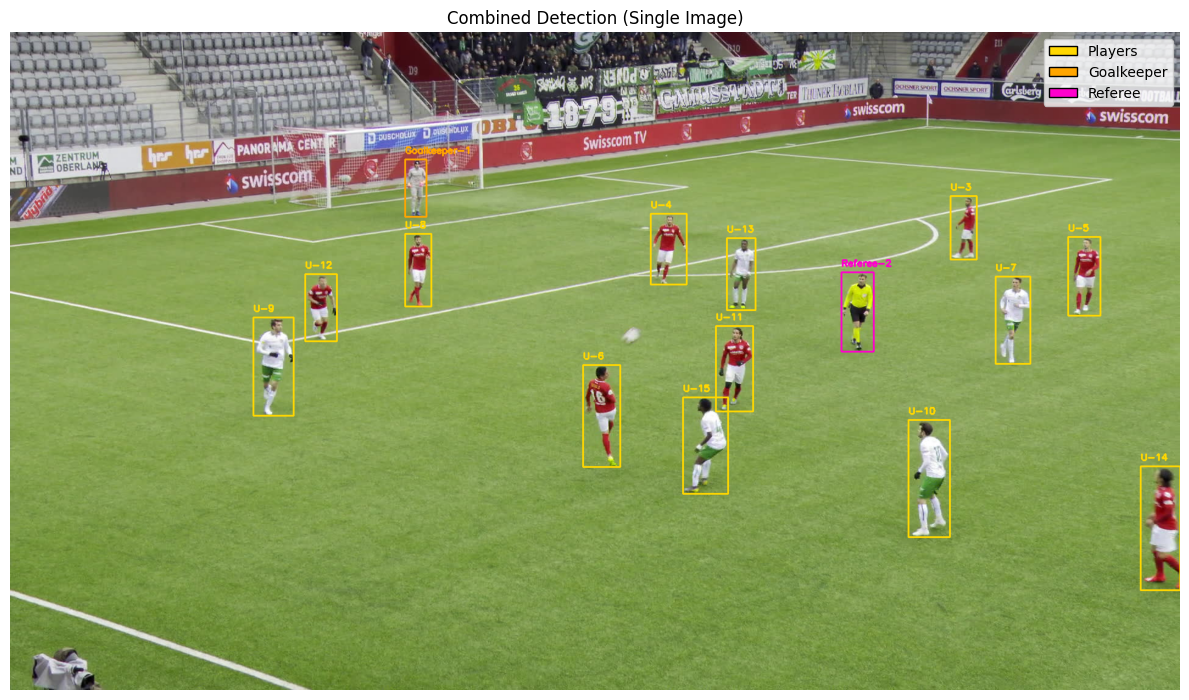

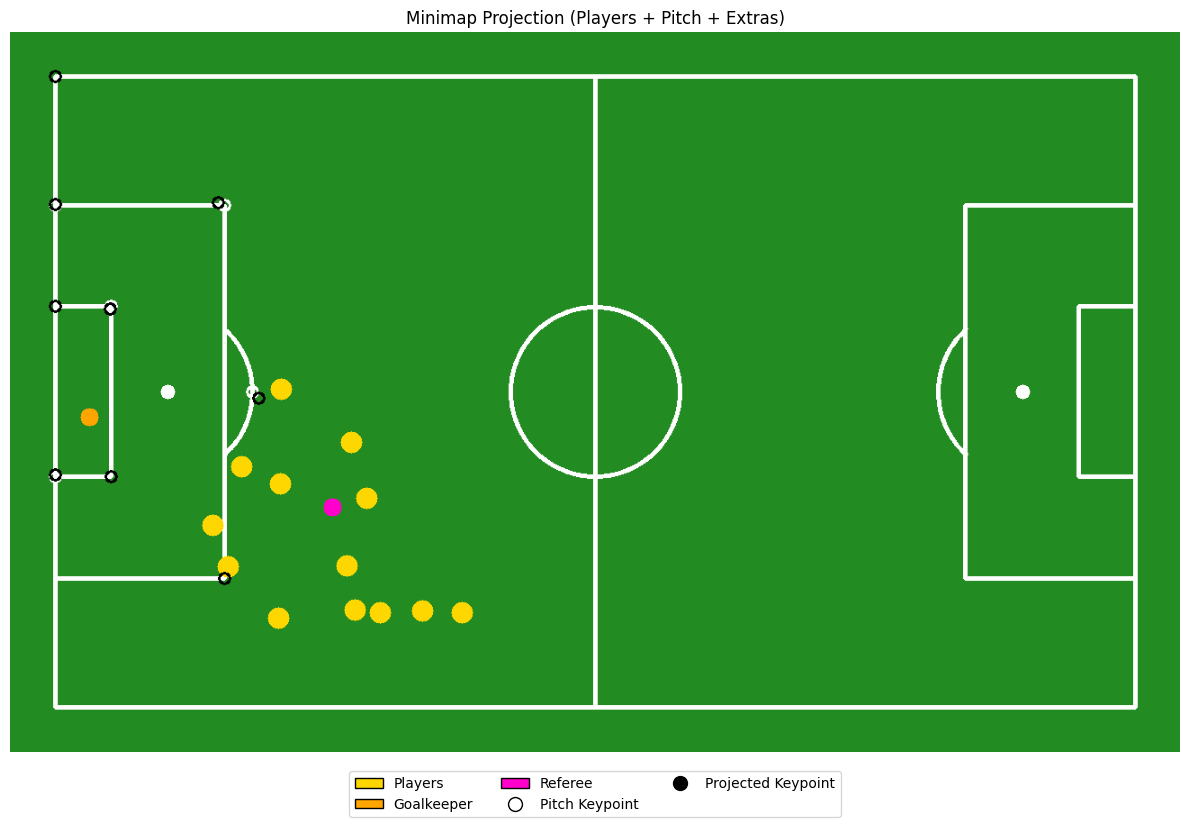

Detection stats:
  Team 0: 0 | Team 1: 0 | Players: 13
  Other classes: 2 | Tracked players: 1
  Class breakdown:
    - Goalkeeper: 1
    - Referee: 1
    - Player: 13


In [18]:
preview_random_clean_image(
    show_edges=False,
    show_vertices=False,
    show_detected_vertices=False,
    show_object_detection=True,
    show_clustering=False,
    show_id=True,
)

In [19]:
def process_video_with_minimap(
    video_path: Path = DEFAULT_VIDEO_PATH,
    output_path: Optional[Path] = None,
    display: bool = False,
    limit_frames: Optional[int] = None,
    init_frames: int = 30,
    show_edges: bool = True,
    show_vertices: bool = True,
    show_detected_vertices: bool = True,
) -> None:
    state = initialize_combined_state(video_path, players_model, num_frames=init_frames)
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open video at {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    writer = None
    if output_path is not None:
        split_sample = compose_split_view(np.zeros((height, width, 3), dtype=np.uint8), BASE_MINIMAP)
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        writer = cv2.VideoWriter(str(output_path), fourcc, fps, (split_sample.shape[1], split_sample.shape[0]))
        print(f"Saving combined video to {output_path}")

    frame_idx = 0
    start = time.time()
    try:
        with ThreadPoolExecutor(max_workers=2) as reader_pool:
            frame_future = reader_pool.submit(cap.read)
            while True:
                ret, frame = frame_future.result()
                if not ret:
                    break

                next_future = reader_pool.submit(cap.read)
                frame_idx += 1
                outputs = process_combined_frame(
                    frame,
                    frame_idx,
                    state,
                    players_model,
                    field_model,
                    PITCH_CONFIG,
                    show_edges=show_edges,
                    show_vertices=show_vertices,
                    show_detected_vertices=show_detected_vertices,
                )
                combined_view = compose_split_view(outputs["frame"], outputs["minimap"])

                if writer is not None:
                    writer.write(combined_view)

                if display:
                    hud = combined_view.copy()
                    cv2.putText(
                        hud,
                        f"Frame {frame_idx}",
                        (10, 30),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        1.0,
                        HUD_COLOR,
                        2,
                    )
                    stats = outputs["stats"]
                    cv2.putText(
                        hud,
                        f"T0:{stats['team_0']} T1:{stats['team_1']} Other:{stats['other']}",
                        (10, 70),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.8,
                        HUD_COLOR,
                        2,
                    )
                    cv2.imshow("Combined View", hud)
                    if cv2.waitKey(1) & 0xFF == ord("q"):
                        frame_future = next_future
                        break

                if limit_frames and frame_idx >= limit_frames:
                    frame_future = next_future
                    break

                if frame_idx % 30 == 0:
                    elapsed = time.time() - start
                    fps_live = frame_idx / elapsed if elapsed else 0
                    stats = outputs["stats"]
                    print(
                        f"Frame {frame_idx} | T0:{stats['team_0']} T1:{stats['team_1']} Other:{stats['other']} | {fps_live:.1f} fps",
                        end="\r",
                    )

                frame_future = next_future
    finally:
        cap.release()
        if writer is not None:
            writer.release()
        if display:
            cv2.destroyAllWindows()
        print("\nProcessing finished")


In [20]:
process_video_with_minimap(
    video_path=DEFAULT_VIDEO_PATH,
    output_path=DEFAULT_VIDEO_PATH.with_suffix(".output.mp4"),
    display=False,
    limit_frames=None,
    init_frames=30,
    show_edges=True,
    show_vertices=True,
    show_detected_vertices=True,
    )

Team color centers (RGB):
 [[     188.16      182.78      185.84]
 [     167.59      144.06      136.43]]
Saving combined video to D:\Project\FootballAnalytix\Data\Sample\Video.output.mp4
Team color centers (RGB):
 [[     188.16      182.78      185.84]
 [     167.59      144.06      136.43]]
Saving combined video to D:\Project\FootballAnalytix\Data\Sample\Video.output.mp4
Frame 750 | T0:1 T1:12 Other:2 | 1.4 fps
Processing finished
Frame 750 | T0:1 T1:12 Other:2 | 1.4 fps
Processing finished
